### Jupyter часть

- [x] Подготовка данных
  - Скачать известный датасет **Титаник** (train и test)
  - Загрузить их как `pandas.DataFrame`
  - Корректно конкатенировать их в один DataFrame по ключу `PassengerID`.
  Отсутствующие данные должны быть `Nan`. Все столбцы должны быть корректных типов, в частности, выживание, класс и пол должны быть категориальными
- [x] Анализ таблицы
  - Визуализировать базовую статистику таблицы. В каком классе было больше всего пассажиров?
  - Группировать таблицу в два уровня: класс и пол, по среднему значению возраста. Кто из возможных комбинаций самый юный, кто самый взрослый? Насколько отличаются эти значения?
  - Отобрать только выживших пассажиров с фамилией, начинающейся на “K”. Отсортировать их по убыванию стоимости билета. Кто заплатил больше всех? Кто меньше всех?
  - Какое максимальное количество родных было с выжившим пассажиром?
- [x] Визуализация
  - Необходимо построить по данным таблицы 10 *различных* графиков на своё усмотрение и фантазию.
  Использовать можно любые средства, однако рекомендуется Seaborn и Plotly.
  - 5 графиков должно быть интерактивными
  - 1 график необходимо сделать 3D
  - Среди представленных графиков должны быть
    - [x] Scatter plot
    - [x] Linear plot (with several lines)
    - [x] Histogram
    - [x] Bar chart
    - [x] Horizontal bar chart
    - [x] Pie chart
    - [x] Box chart
    - [x] Sunburst chart

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
pd.set_option('display.max_columns', None)

# Подготовка данных

In [ ]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [ ]:
titanic_df = pd.merge(train_df, test_df, on='PassengerId', how='outer', suffixes=('_train', '_test'))

# Анализ таблицы

In [ ]:
titanic_df

,PassengerId,Survived,Pclass_train,Name_train,Sex_train,Age_train,SibSp_train,Parch_train,Ticket_train,Fare_train,Cabin_train,Embarked_train,Pclass_test,Name_test,Sex_test,Age_test,SibSp_test,Parch_test,Ticket_test,Fare_test,Cabin_test,Embarked_test
0,1,0.0,3.0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,C85,C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1.0,3.0,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,C123,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,0.0,3.0,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,"Spector, Mr. Woolf",male,NaN,0.0,0.0,A.5. 3236,8.0500,NaN,S
1305,1306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,"Oliva y Ocana, Dona. Fermina",female,39.0,0.0,0.0,PC 17758,108.9000,C105,C
1306,1307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,"Saether, Mr. Simon Sivertsen",male,38.5,0.0,0.0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,"Ware, Mr. Frederick",male,NaN,0.0,0.0,359309,8.0500,NaN,S


In [ ]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PassengerId     1309 non-null   int64  
 1   Survived        891 non-null    float64
 2   Pclass_train    891 non-null    float64
 3   Name_train      891 non-null    object 
 4   Sex_train       891 non-null    object 
 5   Age_train       714 non-null    float64
 6   SibSp_train     891 non-null    float64
 7   Parch_train     891 non-null    float64
 8   Ticket_train    891 non-null    object 
 9   Fare_train      891 non-null    float64
 10  Cabin_train     204 non-null    object 
 11  Embarked_train  889 non-null    object 
 12  Pclass_test     418 non-null    float64
 13  Name_test       418 non-null    object 
 14  Sex_test        418 non-null    object 
 15  Age_test        332 non-null    float64
 16  SibSp_test      418 non-null    float64
 17  Parch_test      418 non-null    f

In [ ]:
titanic_df['Survived'] = titanic_df['Survived'].astype('category')
titanic_df['Pclass_train'] = titanic_df['Pclass_train'].astype('category')
titanic_df['Pclass_test'] = titanic_df['Pclass_test'].astype('category')
titanic_df['Sex_train'] = titanic_df['Sex_train'].astype('category')
titanic_df['Sex_test'] = titanic_df['Sex_test'].astype('category')
titanic_df['Embarked_train'] = titanic_df['Embarked_train'].astype('category')
titanic_df['Embarked_test'] = titanic_df['Embarked_test'].astype('category')

In [ ]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   PassengerId     1309 non-null   int64   
 1   Survived        891 non-null    category
 2   Pclass_train    891 non-null    category
 3   Name_train      891 non-null    object  
 4   Sex_train       891 non-null    category
 5   Age_train       714 non-null    float64 
 6   SibSp_train     891 non-null    float64 
 7   Parch_train     891 non-null    float64 
 8   Ticket_train    891 non-null    object  
 9   Fare_train      891 non-null    float64 
 10  Cabin_train     204 non-null    object  
 11  Embarked_train  889 non-null    category
 12  Pclass_test     418 non-null    category
 13  Name_test       418 non-null    object  
 14  Sex_test        418 non-null    category
 15  Age_test        332 non-null    float64 
 16  SibSp_test      418 non-null    float64 
 17  Parch_test    

# Ответ: в 3 классе было больше всего пассажиров.

,count
Pclass_train,
3.0,491
1.0,216
2.0,184


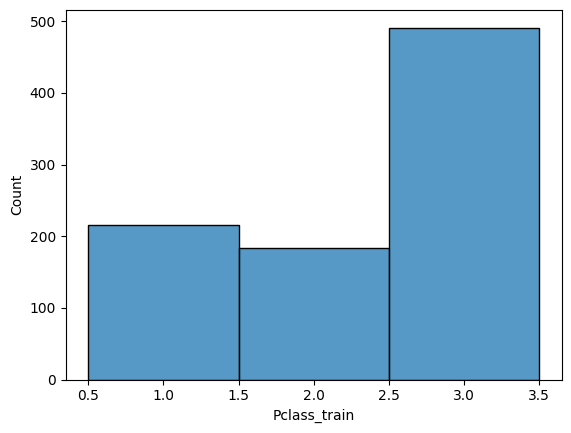

In [ ]:
sns.histplot(titanic_df['Pclass_train'], bins=3)
titanic_df['Pclass_train'].value_counts()

,count
Pclass_test,
3.0,218
1.0,107
2.0,93


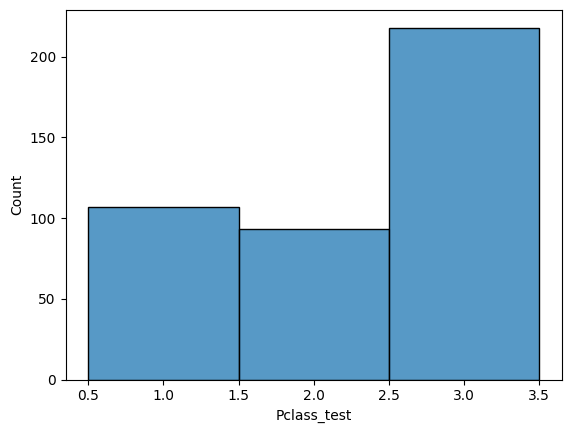

In [ ]:
sns.histplot(titanic_df['Pclass_test'], bins=3)
titanic_df['Pclass_test'].value_counts()

# Ответ: самый юный женщины 3-го класса, самый взрослый мужчины 1-го класса. Эти значения отличаются на 19.5 в первом случае.
# Во втором случае: самые юные женщины 3-го класса, самые взрослые женщины 1-го класса. Эти значения отличаются на 18.3

In [ ]:
titanic_df.groupby(['Pclass_train', 'Sex_train'])['Age_train'].mean()

/tmp/ipython-input-1816100385.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic_df.groupby(['Pclass_train', 'Sex_train'])['Age_train'].mean()


Pclass_train  Sex_train
1.0           female       34.611765
              male         41.281386
2.0           female       28.722973
              male         30.740707
3.0           female       21.750000
              male         26.507589
Name: Age_train, dtype: float64

In [ ]:
titanic_df.groupby(['Pclass_test', 'Sex_test'])['Age_test'].mean()

/tmp/ipython-input-3014738382.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic_df.groupby(['Pclass_test', 'Sex_test'])['Age_test'].mean()


Pclass_test  Sex_test
1.0          female      41.333333
             male        40.520000
2.0          female      24.376552
             male        30.940678
3.0          female      23.073400
             male        24.525104
Name: Age_test, dtype: float64

# Ответ: заплатил больше всех Kimball, Mr. Edwin Nelson Jr, меньше всех Kelly, Miss. Mary

In [ ]:
survivers = titanic_df[titanic_df['Survived'] == 1]
k_surname = survivers[survivers['Name_train'].str.split(',').str[0].str.startswith('K')]
k_surname.sort_values('Fare_train', ascending=False)

,PassengerId,Survived,Pclass_train,Name_train,Sex_train,Age_train,SibSp_train,Parch_train,Ticket_train,Fare_train,Cabin_train,Embarked_train,Pclass_test,Name_test,Sex_test,Age_test,SibSp_test,Parch_test,Ticket_test,Fare_test,Cabin_test,Embarked_test
621,622,1.0,1.0,"Kimball, Mr. Edwin Nelson Jr",male,42.0,1.0,0.0,11753,52.5542,D19,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
457,458,1.0,1.0,"Kenyon, Mrs. Frederick R (Marion)",female,NaN,1.0,0.0,17464,51.8625,D21,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
316,317,1.0,2.0,"Kantor, Mrs. Sinai (Miriam Sternin)",female,24.0,1.0,0.0,244367,26.0000,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
184,185,1.0,3.0,"Kink-Heilmann, Miss. Luise Gretchen",female,4.0,0.0,2.0,315153,22.0250,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
706,707,1.0,2.0,"Kelly, Mrs. Florence ""Fannie""",female,45.0,0.0,0.0,223596,13.5000,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
691,692,1.0,3.0,"Karun, Miss. Manca",female,4.0,0.0,1.0,349256,13.4167,NaN,C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
303,304,1.0,2.0,"Keane, Miss. Nora A",female,NaN,0.0,0.0,226593,12.3500,E101,Q,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
300,301,1.0,3.0,"Kelly, Miss. Anna Katherine ""Annie Kate""",female,NaN,0.0,0.0,9234,7.7500,NaN,Q,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
573,574,1.0,3.0,"Kelly, Miss. Mary",female,NaN,0.0,0.0,14312,7.7500,NaN,Q,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Ответ: максимальное количество родных с выжившим пассажиром было 6.

In [ ]:
survivers['family_size_train'] = survivers['Parch_train'] + survivers['SibSp_train']

print(survivers['family_size_train'].max())

6.0


/tmp/ipython-input-3585161611.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  survivers['family_size_train'] = survivers['Parch_train'] + survivers['SibSp_train']


# Визуализация

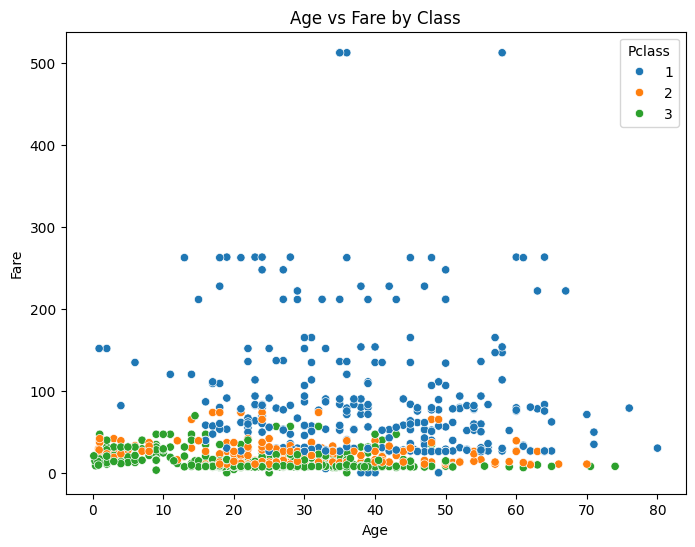

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=titanic_df, x='Age', y='Fare', hue='Pclass')
plt.title('Age vs Fare by Class')
plt.show()

/tmp/ipython-input-2855211539.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.lineplot(data=titanic_df.groupby('Pclass_train')[['Age_train','Fare_train']].mean().reset_index(), x='Pclass_train', y='Age_train', label='Средний возраст')
/tmp/ipython-input-2855211539.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.lineplot(data=titanic_df.groupby('Pclass_train')[['Age_train','Fare_train']].mean().reset_index(), x='Pclass_train', y='Fare_train', label='Средняя стоимость билета')


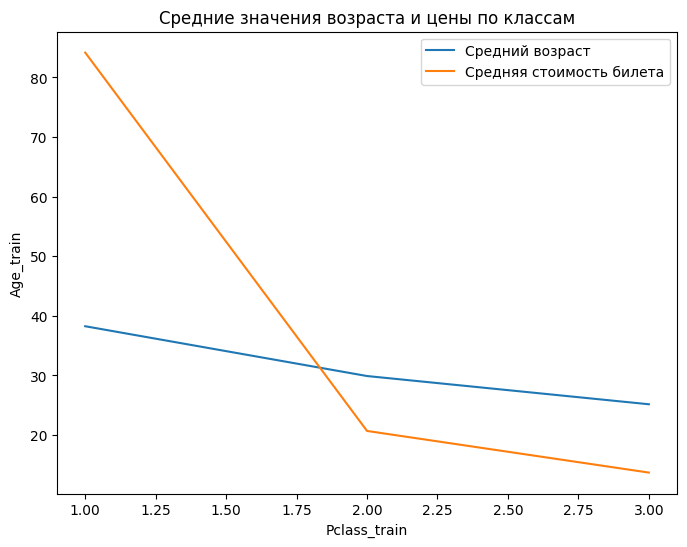

In [ ]:
plt.figure(figsize=(8,6))
sns.lineplot(data=titanic_df.groupby('Pclass_train')[['Age_train','Fare_train']].mean().reset_index(), x='Pclass_train', y='Age_train', label='Средний возраст')
sns.lineplot(data=titanic_df.groupby('Pclass_train')[['Age_train','Fare_train']].mean().reset_index(), x='Pclass_train', y='Fare_train', label='Средняя стоимость билета')
plt.title('Средние значения возраста и цены по классам')
plt.legend()
plt.show()

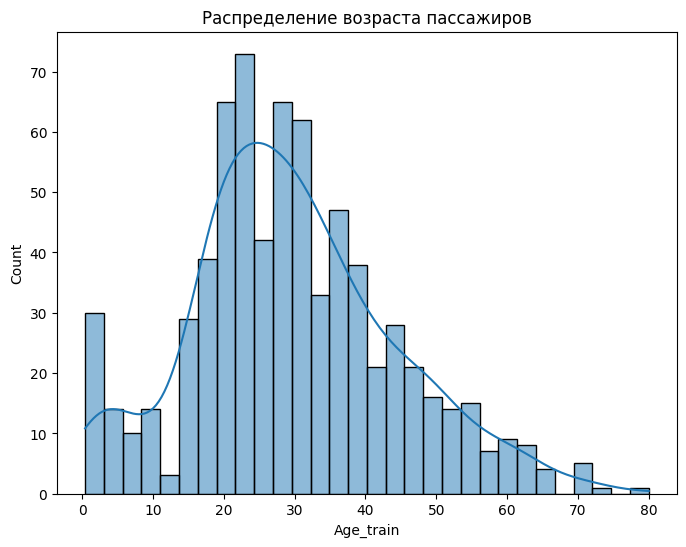

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(titanic_df['Age_train'].dropna(), bins=30, kde=True)
plt.title('Распределение возраста пассажиров')
plt.show()

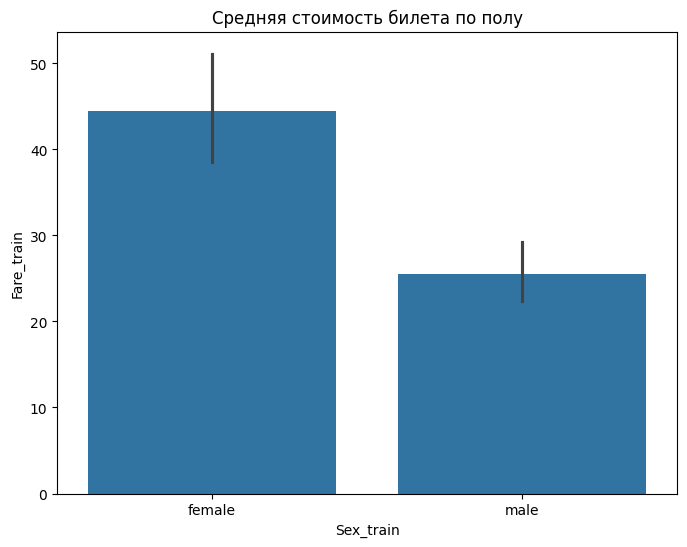

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(data=titanic_df, x='Sex_train', y='Fare_train')
plt.title('Средняя стоимость билета по полу')
plt.show()

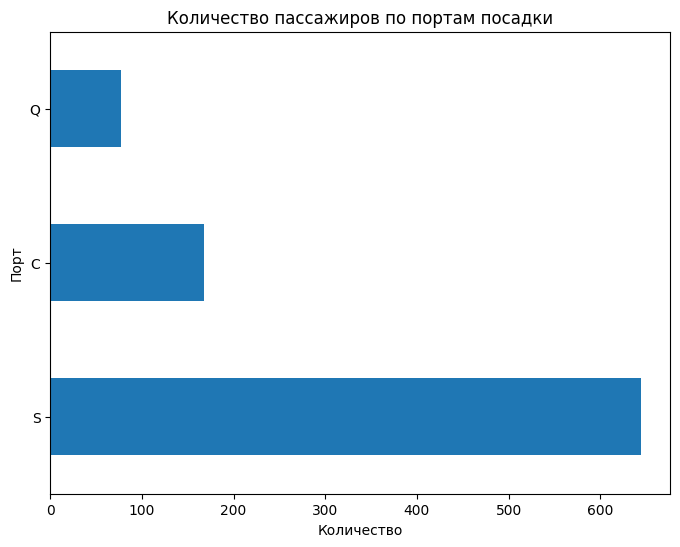

In [ ]:
plt.figure(figsize=(8,6))
titanic_df['Embarked_train'].value_counts().plot(kind='barh')
plt.title('Количество пассажиров по портам посадки')
plt.xlabel('Количество')
plt.ylabel('Порт')
plt.show()

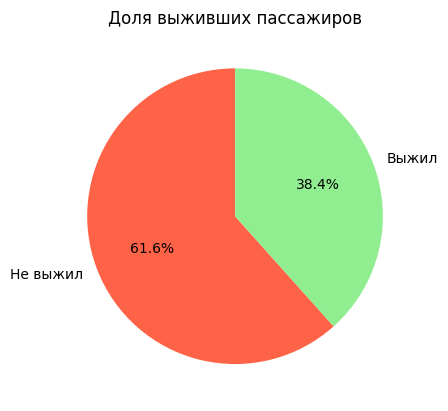

In [ ]:
titanic_df['Survived'].value_counts().plot.pie(autopct='%1.1f%%', labels=['Не выжил', 'Выжил'], colors=['tomato','lightgreen'], startangle=90)
plt.title('Доля выживших пассажиров')
plt.ylabel('')
plt.show()

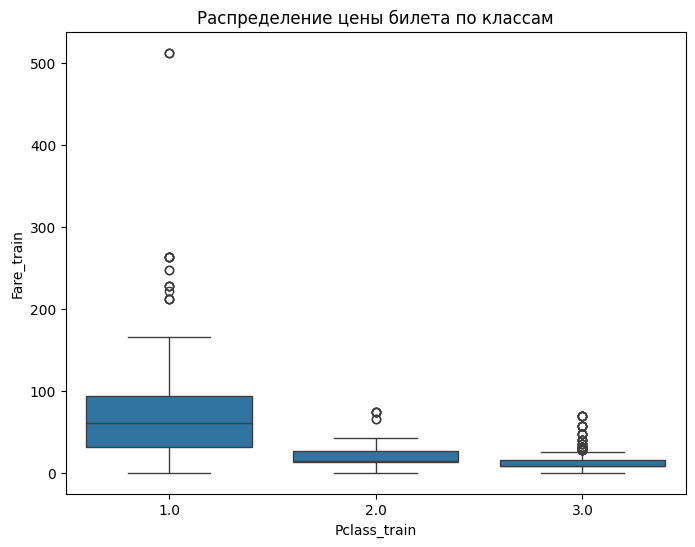

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(data=titanic_df, x='Pclass_train', y='Fare_train')
plt.title('Распределение цены билета по классам')
plt.show()

In [ ]:
fig = px.sunburst(
    titanic_df.dropna(subset=['Survived']),
    path=['Pclass_train', 'Sex_train', 'Survived'],
    values='Fare_train',
    title='Распределение выживших по классам и полу'
)
fig.show()


/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfg = df.groupby(path[i:]).agg(agg_f)
/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfg = df.groupby(path[i:]).agg(agg_f)
/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  

In [ ]:
fig = px.scatter_3d(
    titanic_df.dropna(subset=['Age_train', 'Fare_train']),
    x='Age_train', y='Fare_train', z='Pclass_train',
    color='Sex_train',
    size='Fare_train',
    hover_data=['Name_train'],
    title='3D визуализация: Возраст, стоимость билета и класс пассажиров'
)
fig.show()


In [ ]:
fig = px.box(titanic_df, x='Sex_train', y='Fare_train', color='Pclass_train', title='стоимость билета по полу и классу')
fig.show()

In [ ]:
fig = px.bar(titanic_df, x='Embarked_train', y='Fare_train', color='Sex_train', title='Средняя стоимость билета по портам посадки и полу', barmode='group')
fig.show()

In [ ]:
fig = px.scatter(titanic_df, x='Age_train', y='Fare_train', color='Sex_train', title='Интерактивный график')
fig.show()